# Importando Bibliotecas

In [1]:
import os
try:
    # Configurando diretório de trabalho para 'aulas_teoricas'
    os.chdir('aulas_teoricas')
except FileNotFoundError:
    pass

import logging

# 1. Silencia avisos da camada nativa (C++) do TensorFlow e subprocessos Python
# 0 = todos os logs, 1 = oculta INFO, 2 = oculta INFO e WARNING, 3 = oculta tudo (até ERROR do C++)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONWARNINGS'] = 'ignore'

# 2. Silencia avisos nativos do Python
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# 3. Silencia loggers do TensorFlow e Keras (deve vir logo após importar o TF)
import tensorflow as tf
tf.get_logger().setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)
logging.getLogger('tensorflow').setLevel(logging.ERROR)

In [2]:
# Carregamento de dados
from joblib import load, dump

# Processamento de dados
import pandas as pd
from util import utils as ut
import numpy as np

# Estatística
from scipy.stats import chi2_contingency

# Graficos
import seaborn as sns
import matplotlib.pyplot as plt

# Classificador 
from src.classifier import Classifier

# Importando Dados

In [3]:
# Verificando os arquivos no diretório 'data/df_estruturada'
os.listdir("./data/df_estruturada")

['08_aula_09_X_test',
 '08_aula_09_X_train',
 '08_aula_09_X_valid',
 '08_aula_09_y_test',
 '08_aula_09_y_train',
 '08_aula_09_y_valid']

In [4]:
# Importando os dados de treino
df_train = pd.concat([
    load("./data/df_estruturada/08_aula_09_X_train"),
    load("./data/df_estruturada/08_aula_09_y_train")
], axis=1)
df_train.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe
541,0.060824,0.156681,2054.750574,416.256426,1.728509,0.274165,Alterado,imunodeficiencia
440,0.049927,0.277029,1853.437984,561.318387,1.240507,0.222972,Alterado,imunodeficiencia
482,0.020794,0.169621,3712.239299,1314.103239,1.470395,0.468595,Normal,leucemia
422,0.098734,0.117708,1864.705992,802.282545,1.574182,0.288605,Alterado,imunodeficiencia
778,0.193195,0.109547,2926.017038,1524.468444,2.400111,0.466135,Normal,leucemia


In [5]:
# Importando os dados de treino
df_valid = pd.concat([
    load("./data/df_estruturada/08_aula_09_X_valid"),
    load("./data/df_estruturada/08_aula_09_y_valid")
], axis=1)
df_valid.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe
904,0.205760,0.185144,1735.512581,778.451959,2.228345,0.117692,Alterado,imunodeficiencia
543,0.159611,0.161689,3612.217462,903.493773,2.271285,0.411603,Normal,leucemia
139,0.103551,0.147413,3488.419699,1593.807397,0.532531,0.439125,Normal,cancer
526,0.089775,0.154566,4379.204565,948.954431,1.394407,0.332721,Normal,cancer
868,0.175694,0.205065,3249.381189,1134.132464,0.468055,0.338485,Normal,cancer


In [6]:
# Importando os dados de treino
df_test = pd.concat([
    load("./data/df_estruturada/08_aula_09_X_test"),
    load("./data/df_estruturada/08_aula_09_y_test")
], axis=1)
df_test.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe
557,0.221689,0.237781,3107.839710,1065.934040,1.478703,0.419394,Normal,cancer
798,0.038133,0.239653,3744.296122,1055.014527,1.406982,0.337995,Normal,leucemia
977,0.233695,0.273088,3635.413739,1341.790170,2.114693,0.402492,Normal,cancer
136,0.247209,0.204334,3521.196455,1420.417680,1.050797,0.404243,Normal,cancer
575,0.040772,0.298275,2094.453959,537.993685,2.145163,0.134077,Alterado,imunodeficiencia


# Validação cruzada e busca de hiperparâmetros

## Treino

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'uniform', 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.7686

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.8429



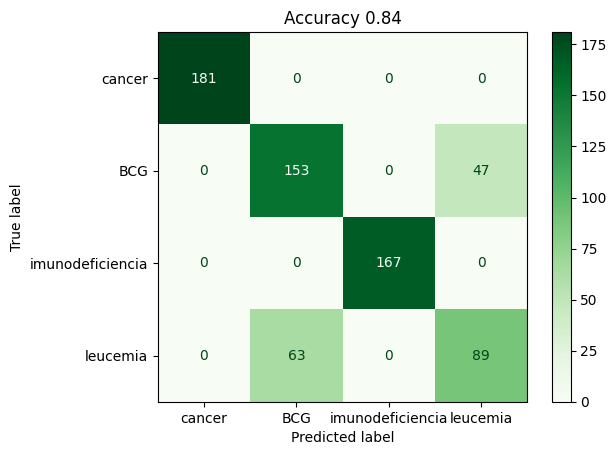


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00       181
          cancer       0.71      0.77      0.74       200
imunodeficiencia       1.00      1.00      1.00       167
        leucemia       0.65      0.59      0.62       152

        accuracy                           0.84       700
       macro avg       0.84      0.84      0.84       700
    weighted avg       0.84      0.84      0.84       700

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    7

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__IFN-γ
3. num__CD3_2
4. num__CD8
5. num__PPD_log
6. num__correlatas
7. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True               True
            num__IFN-γ              True         

In [7]:
classificador = Classifier(
    df=df_train
)

metricas_knn, pred_knn = classificador.classify(modelo='knn')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 2, 'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'linear', 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.7829

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.7829



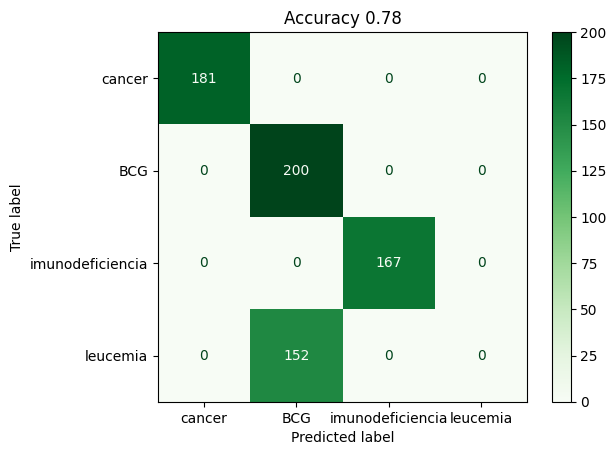


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00       181
          cancer       0.57      1.00      0.72       200
imunodeficiencia       1.00      1.00      1.00       167
        leucemia       0.00      0.00      0.00       152

        accuracy                           0.78       700
       macro avg       0.64      0.75      0.68       700
    weighted avg       0.66      0.78      0.70       700

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    2

--- Lista das Variáveis Selecionadas ---
1. num__IFN-γ
2. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True              False
            num__IFN-γ              True               True
            num__CD3_2              True              False
   

In [8]:
metricas_svm, pred_svm = classificador.classify(modelo='svm')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'rf__criterion': 'gini', 'rf__max_depth': 5, 'rf__min_samples_split': 5, 'rf__n_estimators': 200, 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.7871

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.8257



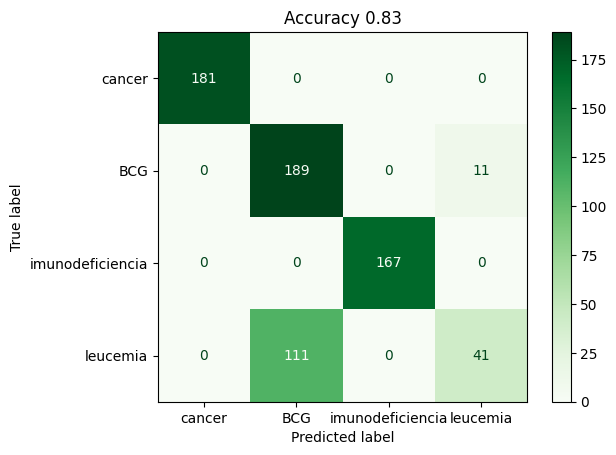


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00       181
          cancer       0.63      0.94      0.76       200
imunodeficiencia       1.00      1.00      1.00       167
        leucemia       0.79      0.27      0.40       152

        accuracy                           0.83       700
       macro avg       0.85      0.80      0.79       700
    weighted avg       0.85      0.83      0.80       700

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    7

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__IFN-γ
3. num__CD3_2
4. num__CD8
5. num__PPD_log
6. num__correlatas
7. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True               True
            num__IFN-γ              True         

In [9]:
metricas_rf, pred_rf = classificador.classify(modelo='rf')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 2, 'gb__learning_rate': 0.01, 'gb__max_depth': 5, 'gb__n_estimators': 100, 'gb__subsample': 1.0, 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.7828

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.8029



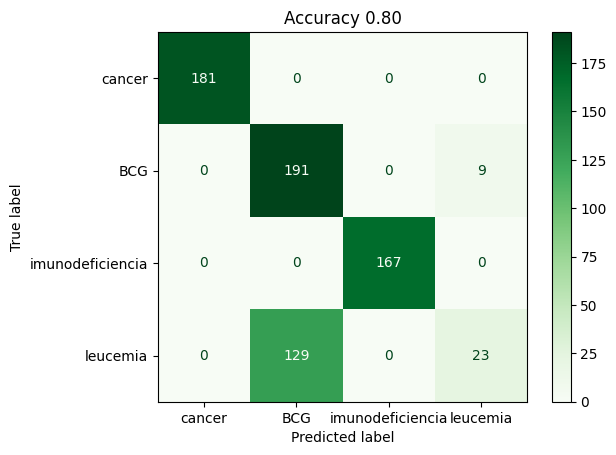


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00       181
          cancer       0.60      0.95      0.73       200
imunodeficiencia       1.00      1.00      1.00       167
        leucemia       0.72      0.15      0.25       152

        accuracy                           0.80       700
       macro avg       0.83      0.78      0.75       700
    weighted avg       0.82      0.80      0.76       700

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    2

--- Lista das Variáveis Selecionadas ---
1. num__IFN-γ
2. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True              False
            num__IFN-γ              True               True
            num__CD3_2              True              False
   

In [10]:
metricas_gbm, pred_gbm = classificador.classify(modelo='gbm')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'nb__var_smoothing': 1.0, 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.7829

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.7829



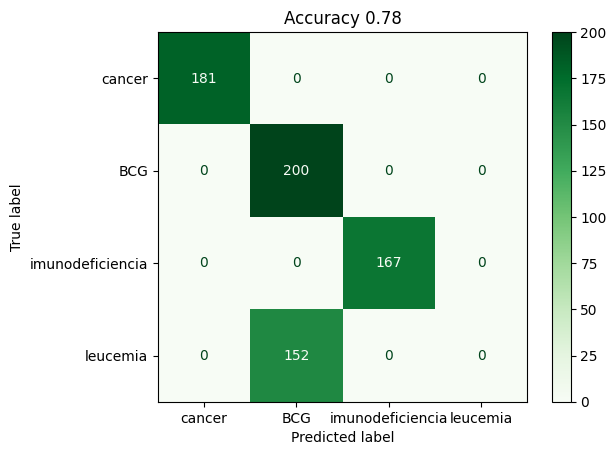


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00       181
          cancer       0.57      1.00      0.72       200
imunodeficiencia       1.00      1.00      1.00       167
        leucemia       0.00      0.00      0.00       152

        accuracy                           0.78       700
       macro avg       0.64      0.75      0.68       700
    weighted avg       0.66      0.78      0.70       700

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    7

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__IFN-γ
3. num__CD3_2
4. num__CD8
5. num__PPD_log
6. num__correlatas
7. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True               True
            num__IFN-γ              True         

In [11]:
metricas_nb, pred_nb = classificador.classify(modelo='nb')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 2, 'mlp__activation': 'relu', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (50,), 'mlp__solver': 'lbfgs', 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.7857

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.7871



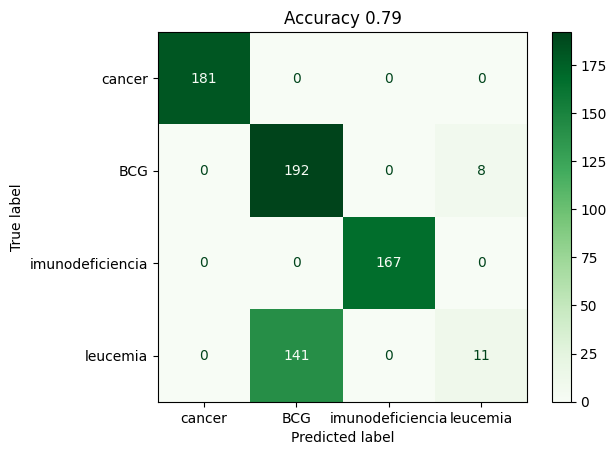


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00       181
          cancer       0.58      0.96      0.72       200
imunodeficiencia       1.00      1.00      1.00       167
        leucemia       0.58      0.07      0.13       152

        accuracy                           0.79       700
       macro avg       0.79      0.76      0.71       700
    weighted avg       0.79      0.79      0.73       700

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    2

--- Lista das Variáveis Selecionadas ---
1. num__IFN-γ
2. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True              False
            num__IFN-γ              True               True
            num__CD3_2              True              False
   

In [12]:
metricas_nn, pred_nn = classificador.classify(modelo='nn')

In [13]:
# Organizando as métricas de treinamento
df_metricas_train = pd.concat([
    metricas_knn.T,
    metricas_svm.T,
    metricas_rf.T,
    metricas_gbm.T,
    metricas_nb.T,
    metricas_nn.T,
])
df_metricas_train.reset_index(inplace=True)
df_metricas_train['modelo'] = ['k-NN']*4 + ['SVM']*4 + ['RF']*4 + ['GBM']*4 + ['NB']*4 + ['NN']*4
df_metricas_train.rename(columns={'index':'metricas', 0:'valores'}, inplace=True)
df_metricas_train.head()

,metricas,valores,modelo
0,Acurácia,0.8429,k-NN
1,Precision,0.8416,k-NN
2,Recall,0.8429,k-NN
3,F1-Score,0.8415,k-NN
4,Acurácia,0.7829,SVM


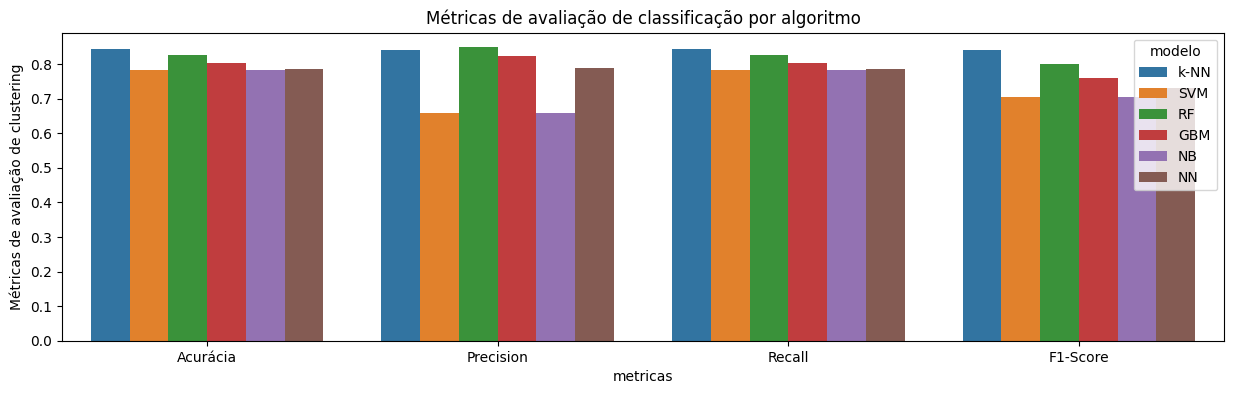

In [14]:
# Gráfico de barras das métricas de avaliação de clustering para os algoritmos
plt.figure(figsize=(15, 4))
plt.title('Métricas de avaliação de classificação por algoritmo')
p = sns.barplot(
    x='metricas',
    y='valores',
    hue='modelo',
    data=df_metricas_train,
)
plt.ylabel('Métricas de avaliação de clustering')

plt.show()

In [15]:
df_train['k-NN'] = pred_knn.copy()
df_train['SVM'] = pred_svm.copy()
df_train['RF'] = pred_rf.copy()
df_train['GBM'] = pred_gbm.copy()
df_train['NB'] = pred_nb.copy()
df_train['NN'] = pred_nn.copy()
df_train.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe,k-NN,SVM,RF,GBM,NB,NN
541,0.060824,0.156681,2054.750574,416.256426,1.728509,0.274165,Alterado,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia
440,0.049927,0.277029,1853.437984,561.318387,1.240507,0.222972,Alterado,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia
482,0.020794,0.169621,3712.239299,1314.103239,1.470395,0.468595,Normal,leucemia,cancer,cancer,cancer,cancer,cancer,cancer
422,0.098734,0.117708,1864.705992,802.282545,1.574182,0.288605,Alterado,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia
778,0.193195,0.109547,2926.017038,1524.468444,2.400111,0.466135,Normal,leucemia,leucemia,cancer,leucemia,cancer,cancer,cancer


## Validação

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'knn__weights': 'uniform', 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.7702

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.8500



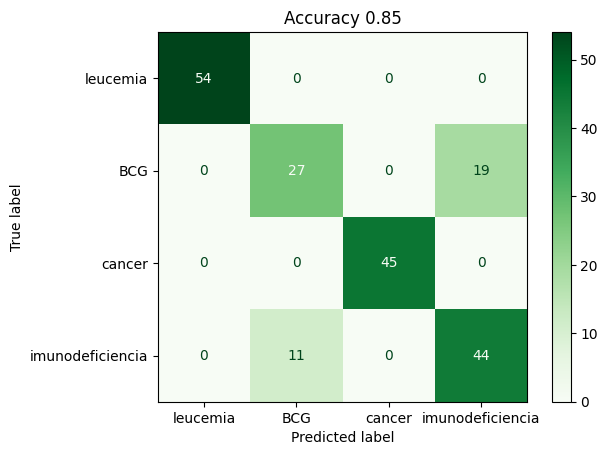


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00        54
          cancer       0.71      0.59      0.64        46
imunodeficiencia       1.00      1.00      1.00        45
        leucemia       0.70      0.80      0.75        55

        accuracy                           0.85       200
       macro avg       0.85      0.85      0.85       200
    weighted avg       0.85      0.85      0.85       200

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    7

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__IFN-γ
3. num__CD3_2
4. num__CD8
5. num__PPD_log
6. num__correlatas
7. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True               True
            num__IFN-γ              True         

In [16]:
classificador = Classifier(
    df=df_valid
)

metricas_knn, pred_knn = classificador.classify(modelo='knn')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf', 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.7700

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.7700



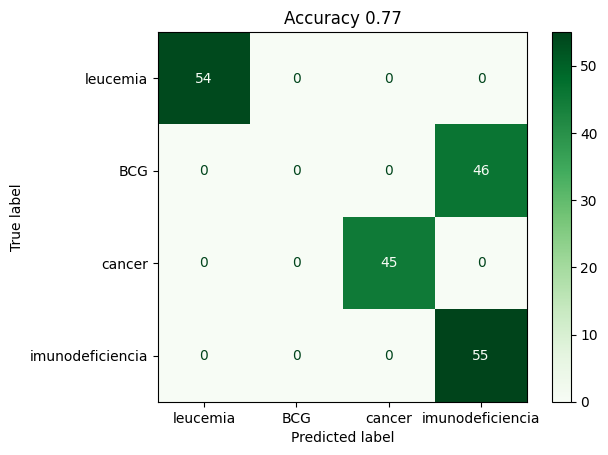


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00        54
          cancer       0.00      0.00      0.00        46
imunodeficiencia       1.00      1.00      1.00        45
        leucemia       0.54      1.00      0.71        55

        accuracy                           0.77       200
       macro avg       0.64      0.75      0.68       200
    weighted avg       0.64      0.77      0.69       200

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    7

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__IFN-γ
3. num__CD3_2
4. num__CD8
5. num__PPD_log
6. num__correlatas
7. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True               True
            num__IFN-γ              True         

In [17]:
metricas_svm, pred_svm = classificador.classify(modelo='svm')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 2, 'rf__criterion': 'entropy', 'rf__max_depth': 5, 'rf__min_samples_split': 5, 'rf__n_estimators': 50, 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.7402

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.8250



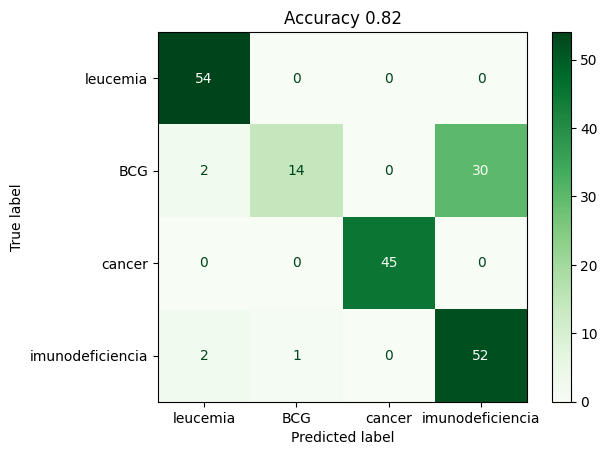


Classification Report:
                  precision    recall  f1-score   support

             BCG       0.93      1.00      0.96        54
          cancer       0.93      0.30      0.46        46
imunodeficiencia       1.00      1.00      1.00        45
        leucemia       0.63      0.95      0.76        55

        accuracy                           0.82       200
       macro avg       0.87      0.81      0.80       200
    weighted avg       0.87      0.82      0.80       200

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    2

--- Lista das Variáveis Selecionadas ---
1. num__PPD_log
2. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True              False
            num__IFN-γ              True              False
            num__CD3_2              True              False
 

In [18]:
metricas_rf, pred_rf = classificador.classify(modelo='rf')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 2, 'gb__learning_rate': 0.01, 'gb__max_depth': 5, 'gb__n_estimators': 50, 'gb__subsample': 1.0, 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.7552

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.7900



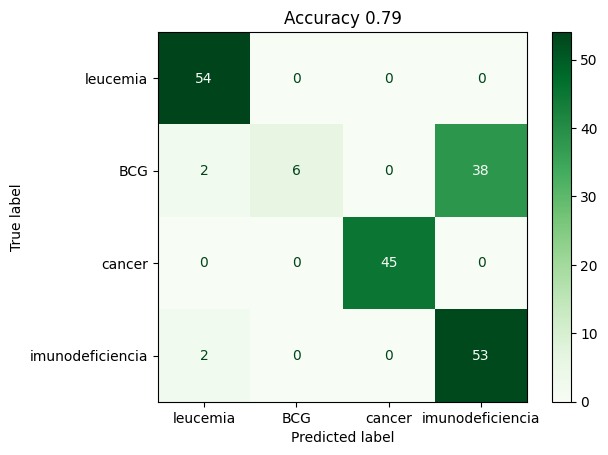


Classification Report:
                  precision    recall  f1-score   support

             BCG       0.93      1.00      0.96        54
          cancer       1.00      0.13      0.23        46
imunodeficiencia       1.00      1.00      1.00        45
        leucemia       0.58      0.96      0.73        55

        accuracy                           0.79       200
       macro avg       0.88      0.77      0.73       200
    weighted avg       0.87      0.79      0.74       200

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    2

--- Lista das Variáveis Selecionadas ---
1. num__PPD_log
2. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True              False
            num__IFN-γ              True              False
            num__CD3_2              True              False
 

In [19]:
metricas_gbm, pred_gbm = classificador.classify(modelo='gbm')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'nb__var_smoothing': 1.0, 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.7698

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.8000



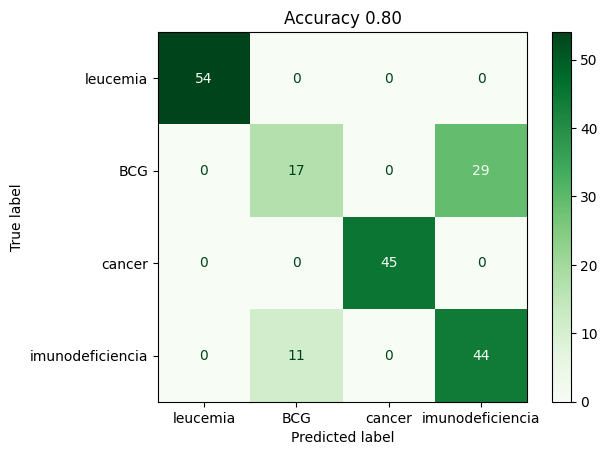


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00        54
          cancer       0.61      0.37      0.46        46
imunodeficiencia       1.00      1.00      1.00        45
        leucemia       0.60      0.80      0.69        55

        accuracy                           0.80       200
       macro avg       0.80      0.79      0.79       200
    weighted avg       0.80      0.80      0.79       200

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    7

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__IFN-γ
3. num__CD3_2
4. num__CD8
5. num__PPD_log
6. num__correlatas
7. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True               True
            num__IFN-γ              True         

In [20]:
metricas_nb, pred_nb = classificador.classify(modelo='nb')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'mlp__activation': 'relu', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (50,), 'mlp__solver': 'adam', 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.7500

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.8550



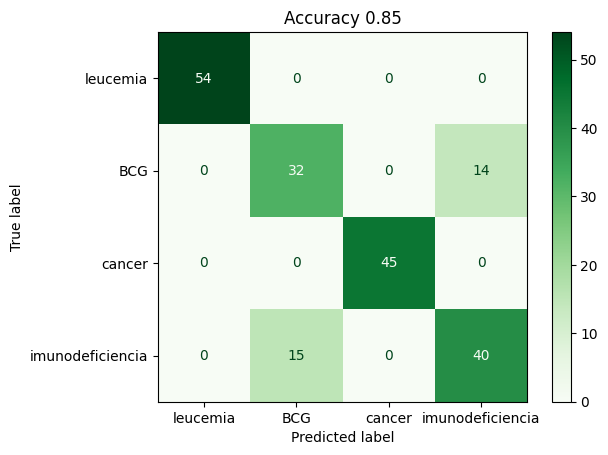


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00        54
          cancer       0.68      0.70      0.69        46
imunodeficiencia       1.00      1.00      1.00        45
        leucemia       0.74      0.73      0.73        55

        accuracy                           0.85       200
       macro avg       0.86      0.86      0.86       200
    weighted avg       0.86      0.85      0.86       200

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    7

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__IFN-γ
3. num__CD3_2
4. num__CD8
5. num__PPD_log
6. num__correlatas
7. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True               True
            num__IFN-γ              True         

In [21]:
metricas_nn, pred_nn = classificador.classify(modelo='nn')

In [22]:
# Organizando as métricas de treinamento
df_metricas_valid = pd.concat([
    metricas_knn.T.copy(),
    metricas_svm.T.copy(),
    metricas_rf.T.copy(),
    metricas_gbm.T.copy(),
    metricas_nb.T.copy(),
    metricas_nn.T.copy(),
])
df_metricas_valid.reset_index(inplace=True)
df_metricas_valid['modelo'] = ['k-NN']*4 + ['SVM']*4 + ['RF']*4 + ['GBM']*4 + ['NB']*4 + ['NN']*4
df_metricas_valid.rename(columns={'index':'metricas', 0:'valores'}, inplace=True)
df_metricas_valid.head()

,metricas,valores,modelo
0,Acurácia,0.8500,k-NN
1,Precision,0.8505,k-NN
2,Recall,0.8500,k-NN
3,F1-Score,0.8479,k-NN
4,Acurácia,0.7700,SVM


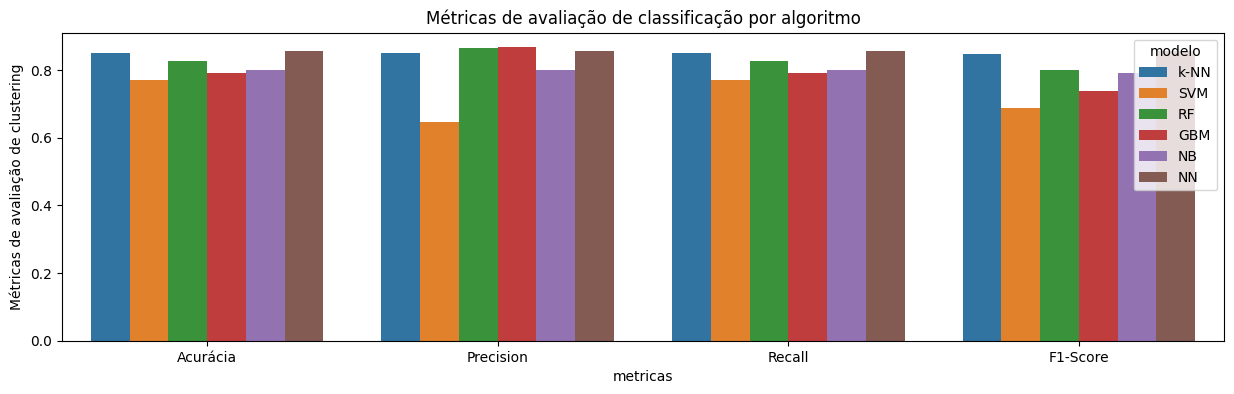

In [23]:
# Gráfico de barras das métricas de avaliação de clustering para os algoritmos
plt.figure(figsize=(15, 4))
plt.title('Métricas de avaliação de classificação por algoritmo')
p = sns.barplot(
    x='metricas',
    y='valores',
    hue='modelo',
    data=df_metricas_valid,
)
plt.ylabel('Métricas de avaliação de clustering')

plt.show()

In [24]:
df_valid['k-NN'] = pred_knn.copy()
df_valid['SVM'] = pred_svm.copy()
df_valid['RF'] = pred_rf.copy()
df_valid['GBM'] = pred_gbm.copy()
df_valid['NB'] = pred_nb.copy()
df_valid['NN'] = pred_nn.copy()
df_valid.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe,k-NN,SVM,RF,GBM,NB,NN
904,0.205760,0.185144,1735.512581,778.451959,2.228345,0.117692,Alterado,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia
543,0.159611,0.161689,3612.217462,903.493773,2.271285,0.411603,Normal,leucemia,cancer,leucemia,leucemia,leucemia,cancer,leucemia
139,0.103551,0.147413,3488.419699,1593.807397,0.532531,0.439125,Normal,cancer,leucemia,leucemia,leucemia,leucemia,leucemia,leucemia
526,0.089775,0.154566,4379.204565,948.954431,1.394407,0.332721,Normal,cancer,leucemia,leucemia,cancer,leucemia,leucemia,cancer
868,0.175694,0.205065,3249.381189,1134.132464,0.468055,0.338485,Normal,cancer,cancer,leucemia,cancer,cancer,cancer,cancer


## Teste

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'distance', 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.8396

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.9700



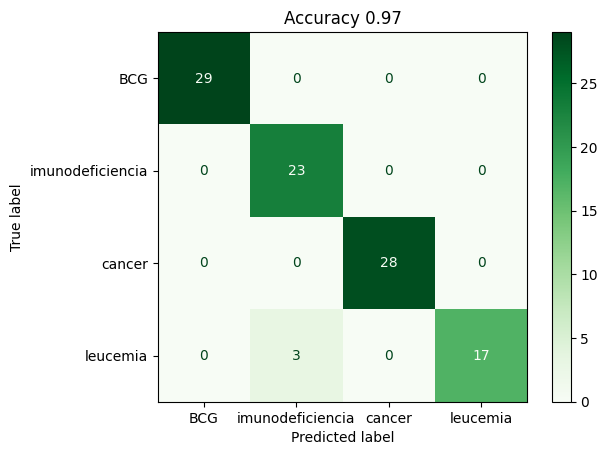


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00        29
          cancer       0.88      1.00      0.94        23
imunodeficiencia       1.00      1.00      1.00        28
        leucemia       1.00      0.85      0.92        20

        accuracy                           0.97       100
       macro avg       0.97      0.96      0.96       100
    weighted avg       0.97      0.97      0.97       100

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    7

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__IFN-γ
3. num__CD3_2
4. num__CD8
5. num__PPD_log
6. num__correlatas
7. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True               True
            num__IFN-γ              True         

In [25]:
classificador = Classifier(
    df=df_test
)

metricas_knn, pred_knn = classificador.classify(modelo='knn')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf', 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.8197

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.8800



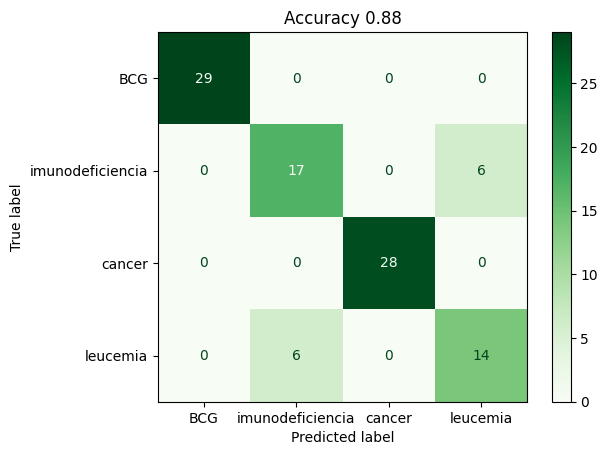


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00        29
          cancer       0.74      0.74      0.74        23
imunodeficiencia       1.00      1.00      1.00        28
        leucemia       0.70      0.70      0.70        20

        accuracy                           0.88       100
       macro avg       0.86      0.86      0.86       100
    weighted avg       0.88      0.88      0.88       100

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    7

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__IFN-γ
3. num__CD3_2
4. num__CD8
5. num__PPD_log
6. num__correlatas
7. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True               True
            num__IFN-γ              True         

In [26]:
metricas_svm, pred_svm = classificador.classify(modelo='svm')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 2, 'rf__criterion': 'gini', 'rf__max_depth': None, 'rf__min_samples_split': 5, 'rf__n_estimators': 100, 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.8197

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.9300



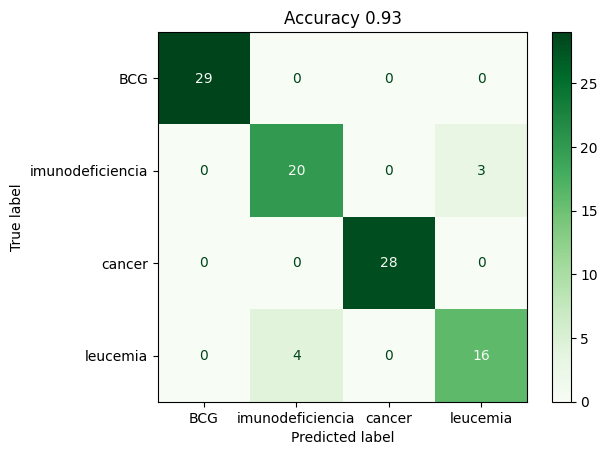


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00        29
          cancer       0.83      0.87      0.85        23
imunodeficiencia       1.00      1.00      1.00        28
        leucemia       0.84      0.80      0.82        20

        accuracy                           0.93       100
       macro avg       0.92      0.92      0.92       100
    weighted avg       0.93      0.93      0.93       100

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    2

--- Lista das Variáveis Selecionadas ---
1. num__IFN-γ
2. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True              False
            num__IFN-γ              True               True
            num__CD3_2              True              False
   

In [27]:
metricas_rf, pred_rf = classificador.classify(modelo='rf')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'gb__learning_rate': 0.1, 'gb__max_depth': 5, 'gb__n_estimators': 50, 'gb__subsample': 1.0, 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.8399

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.9700



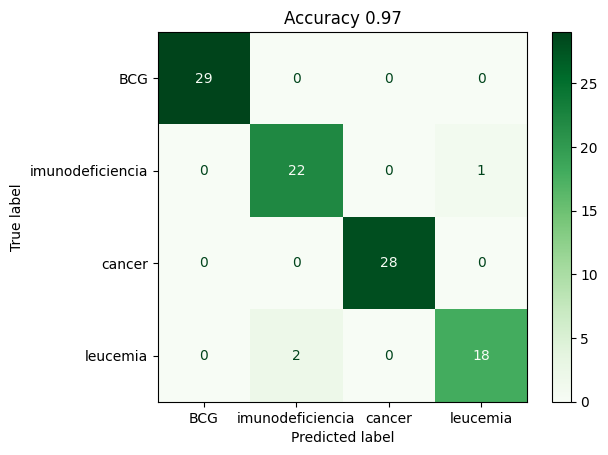


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00        29
          cancer       0.92      0.96      0.94        23
imunodeficiencia       1.00      1.00      1.00        28
        leucemia       0.95      0.90      0.92        20

        accuracy                           0.97       100
       macro avg       0.97      0.96      0.96       100
    weighted avg       0.97      0.97      0.97       100

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    7

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__IFN-γ
3. num__CD3_2
4. num__CD8
5. num__PPD_log
6. num__correlatas
7. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True               True
            num__IFN-γ              True         

In [28]:
metricas_gbm, pred_gbm = classificador.classify(modelo='gbm')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'nb__var_smoothing': 0.1, 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.8102

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.8500



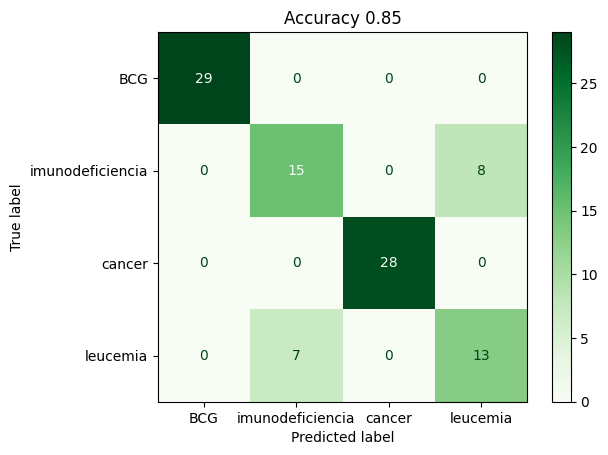


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00        29
          cancer       0.68      0.65      0.67        23
imunodeficiencia       1.00      1.00      1.00        28
        leucemia       0.62      0.65      0.63        20

        accuracy                           0.85       100
       macro avg       0.83      0.83      0.83       100
    weighted avg       0.85      0.85      0.85       100

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    7

--- Lista das Variáveis Selecionadas ---
1. num__TP53
2. num__IFN-γ
3. num__CD3_2
4. num__CD8
5. num__PPD_log
6. num__correlatas
7. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True               True
            num__IFN-γ              True         

In [29]:
metricas_nb, pred_nb = classificador.classify(modelo='nb')

--- Treinando modelo com Pipeline de pré-processamento ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 2, 'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (10,), 'mlp__solver': 'lbfgs', 'var_threshold__threshold': 0.0001}
Melhor acurácia (CV): 0.8399

--- Desempenho no Conjunto de Teste ---
Acurácia final: 0.8600



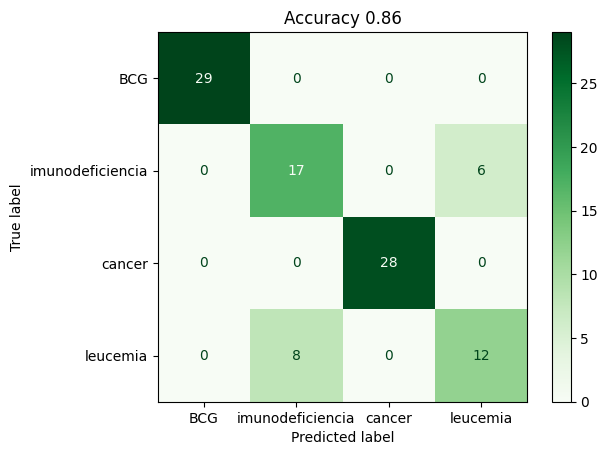


Classification Report:
                  precision    recall  f1-score   support

             BCG       1.00      1.00      1.00        29
          cancer       0.68      0.74      0.71        23
imunodeficiencia       1.00      1.00      1.00        28
        leucemia       0.67      0.60      0.63        20

        accuracy                           0.86       100
       macro avg       0.84      0.83      0.83       100
    weighted avg       0.86      0.86      0.86       100

Total de variáveis originais pré-processadas: 7
Total de variáveis após VarianceThreshold:    7
Total de variáveis selecionadas no modelo:    2

--- Lista das Variáveis Selecionadas ---
1. num__IFN-γ
2. cat__FOXP3_Normal

--- Status de Cada Atributo no Pipeline ---
Atributo_Preprocessado  Passou_Variancia  Selecionado_Final
             num__TP53              True              False
            num__IFN-γ              True               True
            num__CD3_2              True              False
   

In [30]:
metricas_nn, pred_nn = classificador.classify(modelo='nn')

In [31]:
# Organizando as métricas de treinamento
df_metricas_test = pd.concat([
    metricas_knn.T.copy(),
    metricas_svm.T.copy(),
    metricas_rf.T.copy(),
    metricas_gbm.T.copy(),
    metricas_nb.T.copy(),
    metricas_nn.T.copy(),
])
df_metricas_test.reset_index(inplace=True)
df_metricas_test['modelo'] = ['k-NN']*4 + ['SVM']*4 + ['RF']*4 + ['GBM']*4 + ['NB']*4 + ['NN']*4
df_metricas_test.rename(columns={'index':'metricas', 0:'valores'}, inplace=True)
df_metricas_test.head()

,metricas,valores,modelo
0,Acurácia,0.9700,k-NN
1,Precision,0.9735,k-NN
2,Recall,0.9700,k-NN
3,F1-Score,0.9697,k-NN
4,Acurácia,0.8800,SVM


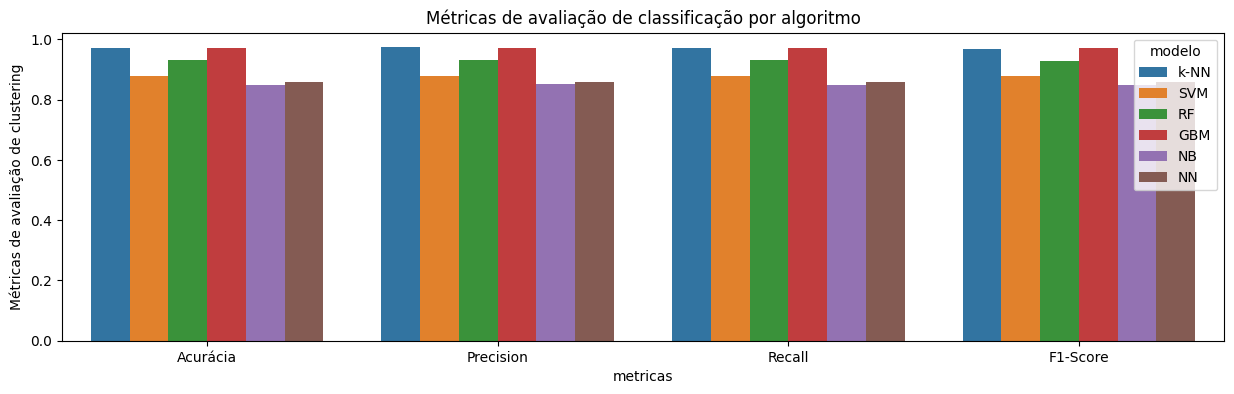

In [32]:
# Gráfico de barras das métricas de avaliação de clustering para os algoritmos
plt.figure(figsize=(15, 4))
plt.title('Métricas de avaliação de classificação por algoritmo')
p = sns.barplot(
    x='metricas',
    y='valores',
    hue='modelo',
    data=df_metricas_test,
)
plt.ylabel('Métricas de avaliação de clustering')

plt.show()

In [33]:
df_test['k-NN'] = pred_knn.copy()
df_test['SVM'] = pred_svm.copy()
df_test['RF'] = pred_rf.copy()
df_test['GBM'] = pred_gbm.copy()
df_test['NB'] = pred_nb.copy()
df_test['NN'] = pred_nn.copy()
df_test.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe,k-NN,SVM,RF,GBM,NB,NN
557,0.221689,0.237781,3107.839710,1065.934040,1.478703,0.419394,Normal,cancer,cancer,cancer,cancer,cancer,cancer,cancer
798,0.038133,0.239653,3744.296122,1055.014527,1.406982,0.337995,Normal,leucemia,leucemia,cancer,leucemia,leucemia,leucemia,cancer
977,0.233695,0.273088,3635.413739,1341.790170,2.114693,0.402492,Normal,cancer,cancer,cancer,cancer,cancer,cancer,cancer
136,0.247209,0.204334,3521.196455,1420.417680,1.050797,0.404243,Normal,cancer,cancer,cancer,cancer,cancer,cancer,cancer
575,0.040772,0.298275,2094.453959,537.993685,2.145163,0.134077,Alterado,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia


# Avalia Modelos

In [34]:
dump(df_train, "./data/08_aula_09_df_train_resultados_classif")
df_train = load("./data/08_aula_09_df_train_resultados_classif")

dump(df_valid, "./data/08_aula_09_df_valid_resultados_classif")
df_valid = load("./data/08_aula_09_df_valid_resultados_classif")

dump(df_test, "./data/08_aula_09_df_test_resultados_classif")
df_test = load("./data/08_aula_09_df_test_resultados_classif")

In [35]:
df_train.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe,k-NN,SVM,RF,GBM,NB,NN
541,0.060824,0.156681,2054.750574,416.256426,1.728509,0.274165,Alterado,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia
440,0.049927,0.277029,1853.437984,561.318387,1.240507,0.222972,Alterado,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia
482,0.020794,0.169621,3712.239299,1314.103239,1.470395,0.468595,Normal,leucemia,cancer,cancer,cancer,cancer,cancer,cancer
422,0.098734,0.117708,1864.705992,802.282545,1.574182,0.288605,Alterado,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia
778,0.193195,0.109547,2926.017038,1524.468444,2.400111,0.466135,Normal,leucemia,leucemia,cancer,leucemia,cancer,cancer,cancer


In [36]:
df_valid.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe,k-NN,SVM,RF,GBM,NB,NN
904,0.205760,0.185144,1735.512581,778.451959,2.228345,0.117692,Alterado,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia
543,0.159611,0.161689,3612.217462,903.493773,2.271285,0.411603,Normal,leucemia,cancer,leucemia,leucemia,leucemia,cancer,leucemia
139,0.103551,0.147413,3488.419699,1593.807397,0.532531,0.439125,Normal,cancer,leucemia,leucemia,leucemia,leucemia,leucemia,leucemia
526,0.089775,0.154566,4379.204565,948.954431,1.394407,0.332721,Normal,cancer,leucemia,leucemia,cancer,leucemia,leucemia,cancer
868,0.175694,0.205065,3249.381189,1134.132464,0.468055,0.338485,Normal,cancer,cancer,leucemia,cancer,cancer,cancer,cancer


In [37]:
df_test.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe,k-NN,SVM,RF,GBM,NB,NN
557,0.221689,0.237781,3107.839710,1065.934040,1.478703,0.419394,Normal,cancer,cancer,cancer,cancer,cancer,cancer,cancer
798,0.038133,0.239653,3744.296122,1055.014527,1.406982,0.337995,Normal,leucemia,leucemia,cancer,leucemia,leucemia,leucemia,cancer
977,0.233695,0.273088,3635.413739,1341.790170,2.114693,0.402492,Normal,cancer,cancer,cancer,cancer,cancer,cancer,cancer
136,0.247209,0.204334,3521.196455,1420.417680,1.050797,0.404243,Normal,cancer,cancer,cancer,cancer,cancer,cancer,cancer
575,0.040772,0.298275,2094.453959,537.993685,2.145163,0.134077,Alterado,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia,imunodeficiencia


In [38]:
def testar_hipotese(df: pd.DataFrame) -> None:
    """
    Testa a hipótese de que a distribuição das classes no treino e no teste é estatisticamente igual (homogênea)
    ou diferente (heterogênea) usando o teste Qui-Quadrado.

    Parâmetros:
        df : pd.DataFrame
            DataFrame contendo as colunas 'Dataset' e 'Classe_Predita'.
        modelo : str
            Nome do modelo para exibição nos resultados.
    Retorna:
        None
    """
    # 3. Criando a Tabela de Contingência (Frequências Observadas)
    tabela_contingencia = pd.crosstab(df['Dataset'], df['Classe_Predita'])
    print("Tabela de Contingência (Observada):")
    print(tabela_contingencia)
    print("-" * 40)

    # 4. Realizando o Teste Qui-Quadrado
    chi2, p_valor, graus_liberdade, frequencias_esperadas = chi2_contingency(tabela_contingencia)

    # 5. Exibindo os resultados
    print(f"Estatística Qui-Quadrado: {chi2:.4f}")
    print(f"Graus de Liberdade: {graus_liberdade}")
    print(f"Valor-p: {p_valor:.4f}")

    # 6. Tomada de Decisão (usando nível de significância de 5%)
    alpha = 0.05
    print("\nConclusão:")
    if p_valor < alpha:
        print("Rejeitamos H0: A distribuição das classes no treino e no teste é ESTATISTICAMENTE DIFERENTE (Heterogênea).")
    else:
        print("Falhamos em rejeitar H0: A distribuição das classes no treino e no teste é ESTATISTICAMENTE IGUAL (Homogênea).")

    return None

In [39]:
modelo = 'k-NN'
link = f"./data/08_aula_09_df_classified_{modelo}"
dump(
    pd.DataFrame({
        'Dataset': ['Treino']*700 + ['Teste']*100,
        'Classe_Predita': np.concatenate([
                                            df_train[modelo].values,
                                            df_test[modelo].values
                                        ])
    }), 
    link
)
df_knn = load(link)
print(modelo)
display(df_knn.head())
testar_hipotese(df_knn)

k-NN


,Dataset,Classe_Predita
0,Treino,imunodeficiencia
1,Treino,imunodeficiencia
2,Treino,cancer
3,Treino,imunodeficiencia
4,Treino,leucemia


Tabela de Contingência (Observada):
Classe_Predita  BCG  cancer  imunodeficiencia  leucemia
Dataset                                                
Teste            29      26                28        17
Treino          181     216               167       136
----------------------------------------
Estatística Qui-Quadrado: 1.8976
Graus de Liberdade: 3
Valor-p: 0.5939

Conclusão:
Falhamos em rejeitar H0: A distribuição das classes no treino e no teste é ESTATISTICAMENTE IGUAL (Homogênea).


In [40]:
modelo = 'SVM'
link = f"./data/08_aula_09_df_classified_{modelo}"
dump(
    pd.DataFrame({
        'Dataset': ['Treino']*700 + ['Teste']*100,
        'Classe_Predita': np.concatenate([
                                            df_train[modelo].values,
                                            df_test[modelo].values
                                        ])
    }), 
    link
)
df_svm = load(link)
print(modelo)
display(df_svm.head())
testar_hipotese(df_svm)

SVM


,Dataset,Classe_Predita
0,Treino,imunodeficiencia
1,Treino,imunodeficiencia
2,Treino,cancer
3,Treino,imunodeficiencia
4,Treino,cancer


Tabela de Contingência (Observada):
Classe_Predita  BCG  cancer  imunodeficiencia  leucemia
Dataset                                                
Teste            29      23                28        20
Treino          181     352               167         0
----------------------------------------
Estatística Qui-Quadrado: 154.8429
Graus de Liberdade: 3
Valor-p: 0.0000

Conclusão:
Rejeitamos H0: A distribuição das classes no treino e no teste é ESTATISTICAMENTE DIFERENTE (Heterogênea).


In [41]:
modelo = 'RF'
link = f"./data/08_aula_09_df_classified_{modelo}"
dump(
    pd.DataFrame({
        'Dataset': ['Treino']*700 + ['Teste']*100,
        'Classe_Predita': np.concatenate([
                                            df_train[modelo].values,
                                            df_test[modelo].values
                                        ])
    }), 
    link
)
df_rf = load(link)
print(modelo)
display(df_rf.head())
testar_hipotese(df_rf)

RF


,Dataset,Classe_Predita
0,Treino,imunodeficiencia
1,Treino,imunodeficiencia
2,Treino,cancer
3,Treino,imunodeficiencia
4,Treino,leucemia


Tabela de Contingência (Observada):
Classe_Predita  BCG  cancer  imunodeficiencia  leucemia
Dataset                                                
Teste            29      24                28        19
Treino          181     300               167        52
----------------------------------------
Estatística Qui-Quadrado: 21.8291
Graus de Liberdade: 3
Valor-p: 0.0001

Conclusão:
Rejeitamos H0: A distribuição das classes no treino e no teste é ESTATISTICAMENTE DIFERENTE (Heterogênea).


In [42]:
modelo = 'GBM'
link = f"./data/08_aula_09_df_classified_{modelo}"
dump(
    pd.DataFrame({
        'Dataset': ['Treino']*700 + ['Teste']*100,
        'Classe_Predita': np.concatenate([
                                            df_train[modelo].values,
                                            df_test[modelo].values
                                        ])
    }), 
    link
)
df_gbm = load(link)
print(modelo)
display(df_gbm.head())
testar_hipotese(df_gbm)

GBM


,Dataset,Classe_Predita
0,Treino,imunodeficiencia
1,Treino,imunodeficiencia
2,Treino,cancer
3,Treino,imunodeficiencia
4,Treino,cancer


Tabela de Contingência (Observada):
Classe_Predita  BCG  cancer  imunodeficiencia  leucemia
Dataset                                                
Teste            29      24                28        19
Treino          181     320               167        32
----------------------------------------
Estatística Qui-Quadrado: 39.1143
Graus de Liberdade: 3
Valor-p: 0.0000

Conclusão:
Rejeitamos H0: A distribuição das classes no treino e no teste é ESTATISTICAMENTE DIFERENTE (Heterogênea).


In [43]:
modelo = 'NB'
link = f"./data/08_aula_09_df_classified_{modelo}"
dump(
    pd.DataFrame({
        'Dataset': ['Treino']*700 + ['Teste']*100,
        'Classe_Predita': np.concatenate([
                                            df_train[modelo].values,
                                            df_test[modelo].values
                                        ])
    }), 
    link
)
df_nb = load(link)
print(modelo)
display(df_nb.head())
testar_hipotese(df_nb)

NB


,Dataset,Classe_Predita
0,Treino,imunodeficiencia
1,Treino,imunodeficiencia
2,Treino,cancer
3,Treino,imunodeficiencia
4,Treino,cancer


Tabela de Contingência (Observada):
Classe_Predita  BCG  cancer  imunodeficiencia  leucemia
Dataset                                                
Teste            29      22                28        21
Treino          181     352               167         0
----------------------------------------
Estatística Qui-Quadrado: 162.9202
Graus de Liberdade: 3
Valor-p: 0.0000

Conclusão:
Rejeitamos H0: A distribuição das classes no treino e no teste é ESTATISTICAMENTE DIFERENTE (Heterogênea).


In [44]:
modelo = 'NN'
link = f"./data/08_aula_09_df_classified_{modelo}"
dump(
    pd.DataFrame({
        'Dataset': ['Treino']*700 + ['Teste']*100,
        'Classe_Predita': np.concatenate([
                                            df_train[modelo].values,
                                            df_test[modelo].values
                                        ])
    }), 
    link
)
df_nn = load(link)
print(modelo)
display(df_nn.head())
testar_hipotese(df_nn)

NN


,Dataset,Classe_Predita
0,Treino,imunodeficiencia
1,Treino,imunodeficiencia
2,Treino,cancer
3,Treino,imunodeficiencia
4,Treino,cancer


Tabela de Contingência (Observada):
Classe_Predita  BCG  cancer  imunodeficiencia  leucemia
Dataset                                                
Teste            29      25                28        18
Treino          181     333               167        19
----------------------------------------
Estatística Qui-Quadrado: 55.1117
Graus de Liberdade: 3
Valor-p: 0.0000

Conclusão:
Rejeitamos H0: A distribuição das classes no treino e no teste é ESTATISTICAMENTE DIFERENTE (Heterogênea).
